<a href="https://colab.research.google.com/github/Gosiuniunia/Sieci-neuronowe/blob/main/OOD_parameters_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import pandas as pd
import warnings
import timm
from timm.layers import DropPath, trunc_normal_
from sklearn.metrics import roc_curve, auc
import os

try:
  import torchinfo
except:
  %pip install torchinfo
  import torchinfo

from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używam urządzenia: {device}")

torch.manual_seed(42)
np.random.seed(42)

Używam urządzenia: cuda


In [3]:
project_directory = "/content/drive/MyDrive/SN/"

PATH_RESNET = project_directory + "model_ResNet18_cifar10_251126.pth"
PATH_CONVNEXT = project_directory + "convnext_2add_epoch_20.pth"
PATH_VIT = project_directory + "ViT_epoch_50.pth"

# Definicje modeli

In [4]:
# ==========================================
# 1. RESNET-18
# ==========================================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()

        self.main_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(output_channels)
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or input_channels != output_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(input_channels, output_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(output_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.main_path(x) + self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, input_channels=3, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            BasicBlock(input_channels=64, output_channels=64, stride=1),
            BasicBlock(input_channels=64, output_channels=64, stride=1)
        )
        self.layer2 = nn.Sequential(
            BasicBlock(input_channels=64, output_channels=128, stride=2),
            BasicBlock(input_channels=128, output_channels=128, stride=1)
        )
        self.layer3 = nn.Sequential(
            BasicBlock(input_channels=128, output_channels=256, stride=2),
            BasicBlock(input_channels=256, output_channels=256, stride=1)
        )
        self.layer4 = nn.Sequential(
            BasicBlock(input_channels=256, output_channels=512, stride=2),
            BasicBlock(input_channels=512, output_channels=512, stride=1)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.classifier(out)
        return out

# ==========================================
# 2. CONVNEXT
# ==========================================
class LayerNorm(nn.Module):
    """ Performs Layer Normalization with inputs shape (batch_size, channels, height, width) or (batch_size, channels) for Global Average Pooling"""
    def __init__(self, normalized_shape, eps=1e-6, gap=False):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.normalized_shape = (normalized_shape, )
        self.gap = gap

    def forward(self, x):
        if self.gap ==True:
          # x: (N, C)
          return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        else:
          # x: (N, C, H, W)
          mean = x.mean(dim=1, keepdim=True)
          var = ((x - mean) ** 2).mean(dim=1, keepdim=True)
          x = (x - mean) / torch.sqrt(var + self.eps)
          return self.weight[:, None, None] * x + self.bias[:, None, None]

class Block(nn.Module):
    """ Basic ConvNeXt Block. Used implementation:
    DwConv -> LayerNorm -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W).
    Architecture was created for ImageNet with image dimension 256x256.
    This implementation was adjusted to CIFAR10."""
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()

        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim) # Original kernel_size=7
        self.norm = LayerNorm(dim) # Layer Normnalization instead of Batch Normalization
        self.pwconv1 = nn.Conv2d(dim, 4 * dim, kernel_size=1)
        self.act = nn.GELU() # GELU activation function instead of ReLu
        self.pwconv2 = nn.Conv2d(4 * dim, dim, kernel_size=1)

        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim)) if layer_scale_init_value > 0 else None # Layer Scale
        self.drop_path = timm.layers.DropPath(drop_path) if drop_path > 0 else nn.Identity() # Stochastic Depth

    def forward(self, x):
        shortcut = x # Residual connection

        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)

        if self.gamma is not None:
            x = self.gamma[:, None, None] * x

        x = shortcut + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    """ Main ConvNeXt architecture adapted for CIFAR10. """
    def __init__(self, in_chans=3, num_classes=10, dims=[64, 128, 256],
                 depths=[2, 4, 6], drop_path_rate=0.1,
                 layer_scale_init_value=1e-6):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=3, stride=1, padding=1), # Original kernel_size=4, stride=4, without padding
            LayerNorm(dims[0])
        )

        # Downsampling layers - layer between every pair of stages
        self.downsampling_layers = nn.ModuleList()
        for i in range(len(dims) - 1):
            self.downsampling_layers.append(nn.Sequential(
                LayerNorm(dims[i]),
                nn.Conv2d(dims[i], dims[i + 1], kernel_size=2, stride=2)
            ))

        # Stages - 4 in original, reduced to 3 for CIFAR10
        self.stages = nn.ModuleList()
        dp_rates = torch.linspace(0, drop_path_rate, sum(depths)).tolist()
        idx = 0

        for d, dim in zip(depths, dims):
            blocks = [Block(dim, drop_path=dp_rates[idx + j], layer_scale_init_value=layer_scale_init_value) for j in range(d)]
            self.stages.append(nn.Sequential(*blocks))
            idx += d

        # Head
        self.norm = LayerNorm(dims[-1], gap=True)
        self.head = nn.Linear(dims[-1], num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)

        for stage, down in zip(self.stages, self.downsampling_layers + [None]):
            x = stage(x)
            if down is not None:
                x = down(x)

        x = self.norm(x.mean([-2, -1])) # Global Average Pooling

        return self.head(x)

# ==========================================
# 3. ViT
# ==========================================

def drop_path(x, drop_prob: float = 0., training: bool = False):
    """
    Drop paths (Stochastic Depth) per sample (gdy jest używane w forward bloku).
    """
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    # Obliczenie maski (B, 1, 1, ...) dla losowego pomijania
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    mask = random_tensor.floor().div(keep_prob)
    return x * mask

class DropPath(nn.Module):
    """
    Moduł DropPath, używający funkcji drop_path.
    """
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=12, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class BlockViT(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, norm_layer=nn.LayerNorm, drop_path_rate=0.0):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0. else nn.Identity()

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=192, depth=12, num_heads=3, mlp_ratio=4, drop_path_rate=0.1):
        super().__init__()

        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size,
                                      in_channels=in_channels, embed_dim=embed_dim)

        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=0.1)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]

        self.blocks = nn.ModuleList([
            BlockViT(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                drop_path_rate=dpr[i]
            )
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]

        x = self.patch_embed(x)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        cls_token_output = x[:, 0]
        x = self.head(cls_token_output)

        return x

# Datasety

In [5]:
BATCH_SIZE = 128
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

ds_id = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
loader_id = DataLoader(ds_id, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

ds_near = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
loader_near = DataLoader(ds_near, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

ds_far = datasets.SVHN(root='./data', split='test', download=True, transform=transform_test) # trchę mały ten zbiór
loader_far = DataLoader(ds_far, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dane gotowe:\n - ID (CIFAR10): {len(ds_id)}\n - Near (CIFAR100): {len(ds_near)}\n - Far (SVHN): {len(ds_far)}")

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]
100%|██████████| 169M/169M [00:13<00:00, 12.2MB/s]
100%|██████████| 64.3M/64.3M [00:11<00:00, 5.52MB/s]


Dane gotowe:
 - ID (CIFAR10): 10000
 - Near (CIFAR100): 10000
 - Far (SVHN): 26032


# Ładowanie modeli

In [6]:
def load_model(model_class, model_path, device, **kwargs):
    print(f"Ładowanie modelu z: {model_path}")
    model = model_class(**kwargs)

    try:
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint)
    except Exception as e:
        print(f"Błąd ładowania wag: {e}")
        return None

    model.to(device)
    model.eval()
    return model

In [7]:
model_resnet = load_model(ResNet18, PATH_RESNET, device, num_classes=10)
model_convnext = load_model(ConvNeXt, PATH_CONVNEXT, device)
model_vit = load_model(VisionTransformer, PATH_VIT, device)

Ładowanie modelu z: /content/drive/MyDrive/SN/model_ResNet18_cifar10_251126.pth
Ładowanie modelu z: /content/drive/MyDrive/SN/convnext_2add_epoch_20.pth
Ładowanie modelu z: /content/drive/MyDrive/SN/ViT_epoch_50.pth


In [8]:
models_info = [
    # name     , model         , subtitle
    ("resnet"  , model_resnet  , "ResNet18"),
    ("convnext", model_convnext, "ConvNeXt"),
    ("vit"     , model_vit     , "ViT")
]

# Definicje metod OOD

In [9]:
def get_msp_scores(model, loader, device):
    scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # Forward pass (logity)
            logits = model(images)
            # Softmax (zamiana na prawdopodobieństwa)
            probs = F.softmax(logits, dim=1)
            # Maximum (bierzemy najwyższe prawdopodobieństwo dla każdej próbki)
            max_probs, _ = torch.max(probs, dim=1)

            scores.extend(max_probs.cpu().numpy())

    return np.array(scores) #Im wyższy wynik, tym model jest pewniejszy (czyli myśli, że to In-Distribution)

In [10]:
def get_energy_scores(model, loader, device, T=1.0):
    model.eval()
    scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)

            # E(x) = -T * logsumexp(x/T)
            outputs_div_T = logits / T
            energy = -T * torch.logsumexp(outputs_div_T, dim=1)
            ood_score = -energy # wynik to -Energy (im wyższy, tym bardziej ID)

            scores.append(ood_score.cpu().numpy())

    return np.concatenate(scores)

In [11]:
def get_odin_scores(model, loader, device, T=1000.0, epsilon=0.0014):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    scores = []

    for images, labels in loader:
        images = images.to(device)
        images.requires_grad = True

        outputs = model(images)

        # Używamy predicted labels jako celu, bo chcemy zwiększyć pewność tej właśnie decyzji
        predicted_labels = outputs.max(1)[1]

        outputs_scaled = outputs / T
        loss = criterion(outputs_scaled, predicted_labels)
        loss.backward()

        # Perturbacja (FGSM-like)
        # Gradient lossa pokazuje kierunek zwiększania błędu, chcmey zmiejszyć błąd (zwiększyć pewność), więc idziemy w przeciwną stronę (- sign(grad)).
        gradient = images.grad.data
        temp_inputs = images - epsilon * torch.sign(gradient)

        with torch.no_grad():
            outputs_new = model(temp_inputs)
            outputs_new = outputs_new / T
            probs = F.softmax(outputs_new, dim=1)
            max_probs, _ = torch.max(probs, dim=1)

            scores.append(max_probs.cpu().numpy())

        model.zero_grad()
        images.requires_grad = False

    return np.concatenate(scores)

# Dobór parametrów dla metod ODIN i Energy-based



### Uzasadnienie doboru metryk:
- *AUROC*: Sprowadza całą krzywą ROC do jednej liczby, która mówi, jakie jest prawdopodobieństwo, że model oceni losową próbkę ID jako "bardziej pewną" niż próbkę OoD.

- *FPR@95* (False Positive Rate at 95% True Positive Rate) mówi, jaki odsetek danych obcych (OoD) zostanie błędnie zaakceptowany przez system, gdy ustalimy próg tak, aby poprawnie rozpoznawał 95% danych znanych (ID).

### Testowane wartości

- T = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

- ϵ 21 równomiernie rozłożonych liczb od 0 do 0.004

In [12]:
def calculate_scores(model, loader, method, T=1.0, noise_magnitude=0.0):
    if method == 'msp':
        return get_msp_scores(model, loader, device)
    elif method == 'energy':
        return get_energy_scores(model, loader, device, T=T)
    elif method == 'odin':
        return get_odin_scores(model, loader, device, T=T, epsilon=noise_magnitude)

In [13]:
def calc_fpr_at_95_tpr(id_scores, ood_scores):
    # 1 = ID, 0 = OOD
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Znajdź FPR dla TPR >= 0.95
    target_tpr = 0.95
    if np.max(tpr) < target_tpr:
        return 1.0 # Najgorszy przypadek

    idx = np.searchsorted(tpr, target_tpr)
    return fpr[idx]

In [15]:
models_to_test = {
   "ResNet18": model_resnet,
   "ConvNeXt": model_convnext,
   "ViT": model_vit
}

Ts = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
eps = np.linspace(0, 0.004, 21)
methods = []

for t in Ts:
    methods.append({'name': 'Energy', 'type': 'energy', 'T': t, 'eps': None})

for t in Ts:
    for e in eps:
        methods.append({'name': 'ODIN', 'type': 'odin', 'T': t, 'eps': e})

results_list = []
idx = 1

for model_name, model in models_to_test.items():
    print(f"\n{'='*40}")
    print(f"ANALIZA MODELU: {model_name}")
    print(f"{'='*40}")

    for m in methods:
        print(f"[{idx}/{len(methods)}] --> Metoda: {m['name']} (T={m['T']})")

        id_scores = calculate_scores(model, loader_id, method=m['type'], T=m['T'], noise_magnitude=m['eps'])
        near_scores = calculate_scores(model, loader_near, method=m['type'], T=m['T'], noise_magnitude=m['eps'])
        far_scores = calculate_scores(model, loader_far, method=m['type'], T=m['T'], noise_magnitude=m['eps'])

        # Near-OOD
        y_true_near = np.concatenate([np.ones(len(id_scores)), np.zeros(len(near_scores))])
        y_scores_near = np.concatenate([id_scores, near_scores])
        auroc_near = roc_auc_score(y_true_near, y_scores_near)
        fpr_near = calc_fpr_at_95_tpr(id_scores, near_scores)

        # Far-OOD
        y_true_far = np.concatenate([np.ones(len(id_scores)), np.zeros(len(far_scores))])
        y_scores_far = np.concatenate([id_scores, far_scores])
        auroc_far = roc_auc_score(y_true_far, y_scores_far)
        fpr_far = calc_fpr_at_95_tpr(id_scores, far_scores)

        results_list.append({
            'Architektura': model_name,
            'Metoda': m['name'],
            'T': m['T'],
            'EPS': m['eps'],
            'Near (C100) AUROC': auroc_near,
            'Near (C100) FPR@95': fpr_near,
            'Far (SVHN) AUROC': auroc_far,
            'Far (SVHN) FPR@95': fpr_far
        })

        idx += 1
        plt.show()

df_results = pd.DataFrame(results_list)

print("\n=== PODSUMOWANIE WYNIKÓW ===")
pd.options.display.float_format = '{:,.4f}'.format
print(df_results)

csv_path = os.path.join(project_directory, f"results_full.csv")
df_results.to_csv(csv_path, index=False)
print(f"\nTabela wyników zapisana: {csv_path}")


ANALIZA MODELU: ResNet18
[1/220] --> Metoda: Energy (T=1)
[2/220] --> Metoda: Energy (T=2)
[3/220] --> Metoda: Energy (T=5)
[4/220] --> Metoda: Energy (T=10)
[5/220] --> Metoda: Energy (T=20)
[6/220] --> Metoda: Energy (T=50)
[7/220] --> Metoda: Energy (T=100)
[8/220] --> Metoda: Energy (T=200)
[9/220] --> Metoda: Energy (T=500)
[10/220] --> Metoda: Energy (T=1000)
[11/220] --> Metoda: ODIN (T=1)
[12/220] --> Metoda: ODIN (T=1)
[13/220] --> Metoda: ODIN (T=1)
[14/220] --> Metoda: ODIN (T=1)
[15/220] --> Metoda: ODIN (T=1)
[16/220] --> Metoda: ODIN (T=1)
[17/220] --> Metoda: ODIN (T=1)
[18/220] --> Metoda: ODIN (T=1)
[19/220] --> Metoda: ODIN (T=1)
[20/220] --> Metoda: ODIN (T=1)
[21/220] --> Metoda: ODIN (T=1)
[22/220] --> Metoda: ODIN (T=1)
[23/220] --> Metoda: ODIN (T=1)
[24/220] --> Metoda: ODIN (T=1)
[25/220] --> Metoda: ODIN (T=1)
[26/220] --> Metoda: ODIN (T=1)
[27/220] --> Metoda: ODIN (T=1)
[28/220] --> Metoda: ODIN (T=1)
[29/220] --> Metoda: ODIN (T=1)
[30/220] --> Metoda: OD

# Wizualizacja dla Enery-based

In [17]:
filepath = '/content/drive/MyDrive/SN/results_full.csv'
df_results = pd.read_csv(filepath)

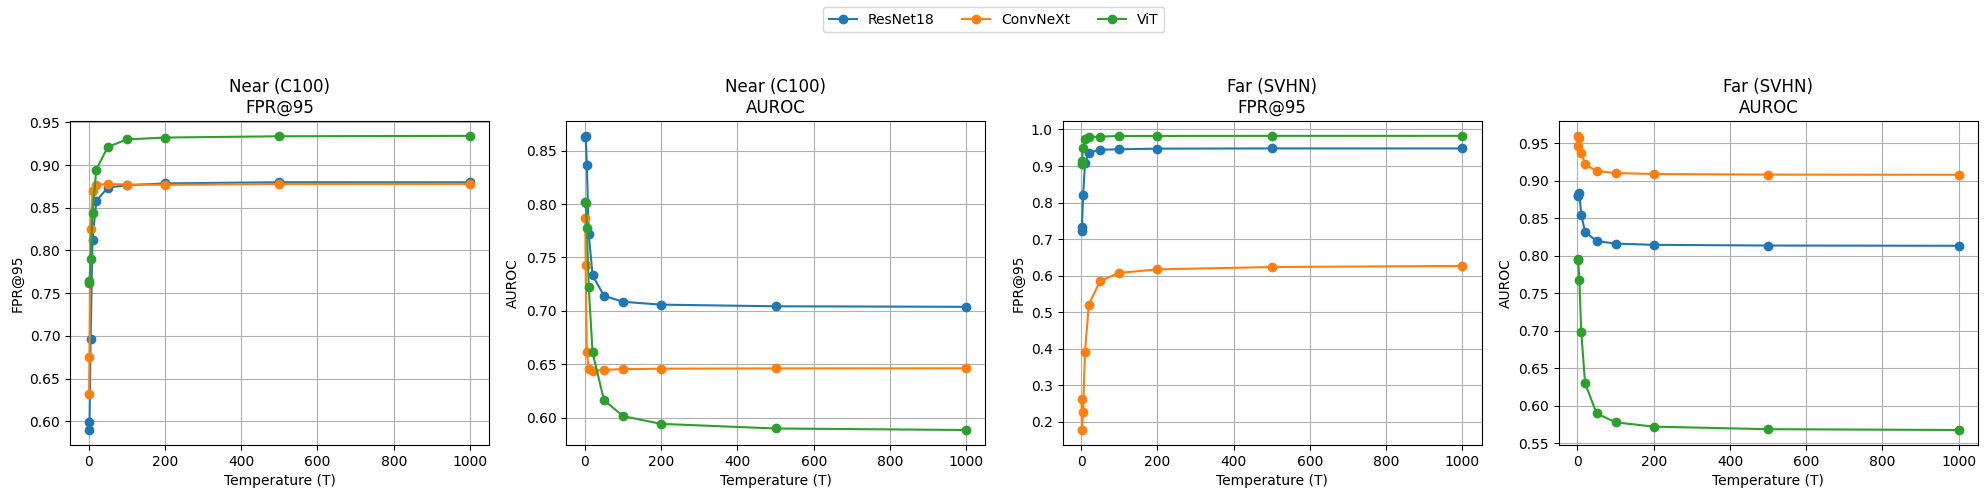

In [23]:
df_energy = df_results[df_results['Metoda'] == 'Energy']
architectures = df_energy['Architektura'].unique()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)

# --- Near: FPR@95 ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[0].plot(sub['T'], sub['Near (C100) FPR@95'], marker='o', label=arch)

axes[0].set_title('Near (C100)\nFPR@95')
axes[0].set_xlabel('Temperature (T)')
axes[0].set_ylabel('FPR@95')
axes[0].grid(True)

# --- Near: AUROC ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[1].plot(sub['T'], sub['Near (C100) AUROC'], marker='o')

axes[1].set_title('Near (C100)\nAUROC')
axes[1].set_xlabel('Temperature (T)')
axes[1].set_ylabel('AUROC')
axes[1].grid(True)

# --- Far: FPR@95 ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[2].plot(sub['T'], sub['Far (SVHN) FPR@95'], marker='o')

axes[2].set_title('Far (SVHN)\nFPR@95')
axes[2].set_xlabel('Temperature (T)')
axes[2].set_ylabel('FPR@95')
axes[2].grid(True)

# --- Far: AUROC ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[3].plot(sub['T'], sub['Far (SVHN) AUROC'], marker='o')

axes[3].set_title('Far (SVHN)\nAUROC')
axes[3].set_xlabel('Temperature (T)')
axes[3].set_ylabel('AUROC')
axes[3].grid(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(architectures))
plt.tight_layout(rect=[0, 0, 1, 0.88])
filename = f"Energy_temperature_plot.png"
plt.savefig(os.path.join("/content/drive/MyDrive/SN/", filename), dpi=100)
plt.show()


# Wizualizacja dla ODIN

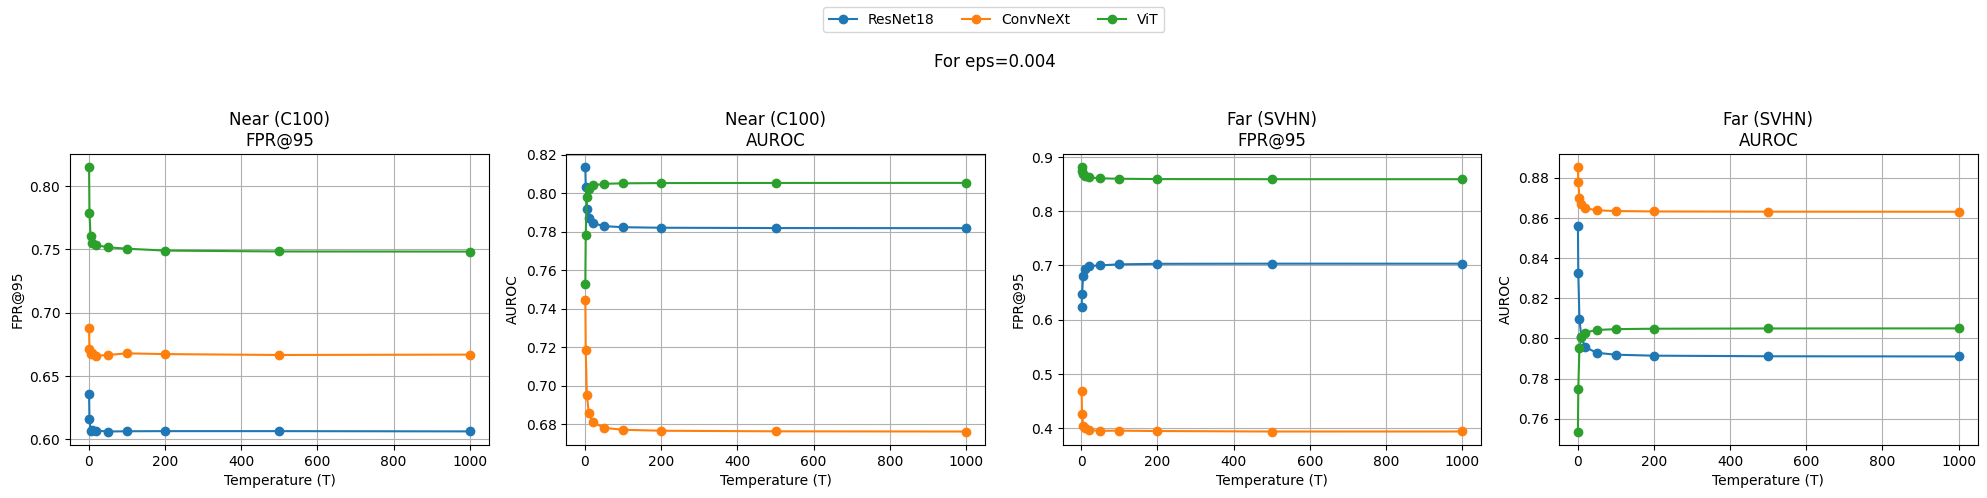

In [36]:
eps_val = 0.004
df_odin = df_results[df_results['Metoda'] == 'ODIN']
df_odin_eps = df_odin[df_odin['EPS'] == eps_val]
architectures = df_odin_eps['Architektura'].unique()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
fig.suptitle(f"For eps={eps_val}", y=0.9)

# --- Near: FPR@95 ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[0].plot(sub['T'], sub['Near (C100) FPR@95'], marker='o', label=arch)

axes[0].set_title('Near (C100)\nFPR@95')
axes[0].set_xlabel('Temperature (T)')
axes[0].set_ylabel('FPR@95')
axes[0].grid(True)

# --- Near: AUROC ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[1].plot(sub['T'], sub['Near (C100) AUROC'], marker='o')

axes[1].set_title('Near (C100)\nAUROC')
axes[1].set_xlabel('Temperature (T)')
axes[1].set_ylabel('AUROC')
axes[1].grid(True)

# --- Far: FPR@95 ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[2].plot(sub['T'], sub['Far (SVHN) FPR@95'], marker='o')

axes[2].set_title('Far (SVHN)\nFPR@95')
axes[2].set_xlabel('Temperature (T)')
axes[2].set_ylabel('FPR@95')
axes[2].grid(True)

# --- Far: AUROC ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[3].plot(sub['T'], sub['Far (SVHN) AUROC'], marker='o')

axes[3].set_title('Far (SVHN)\nAUROC')
axes[3].set_xlabel('Temperature (T)')
axes[3].set_ylabel('AUROC')
axes[3].grid(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(architectures))
plt.tight_layout(rect=[0, 0, 1, 0.88])
filename = f"ODIN_eps={eps_val}.png"
plt.savefig(os.path.join("/content/drive/MyDrive/SN/", filename), dpi=100)
plt.show()


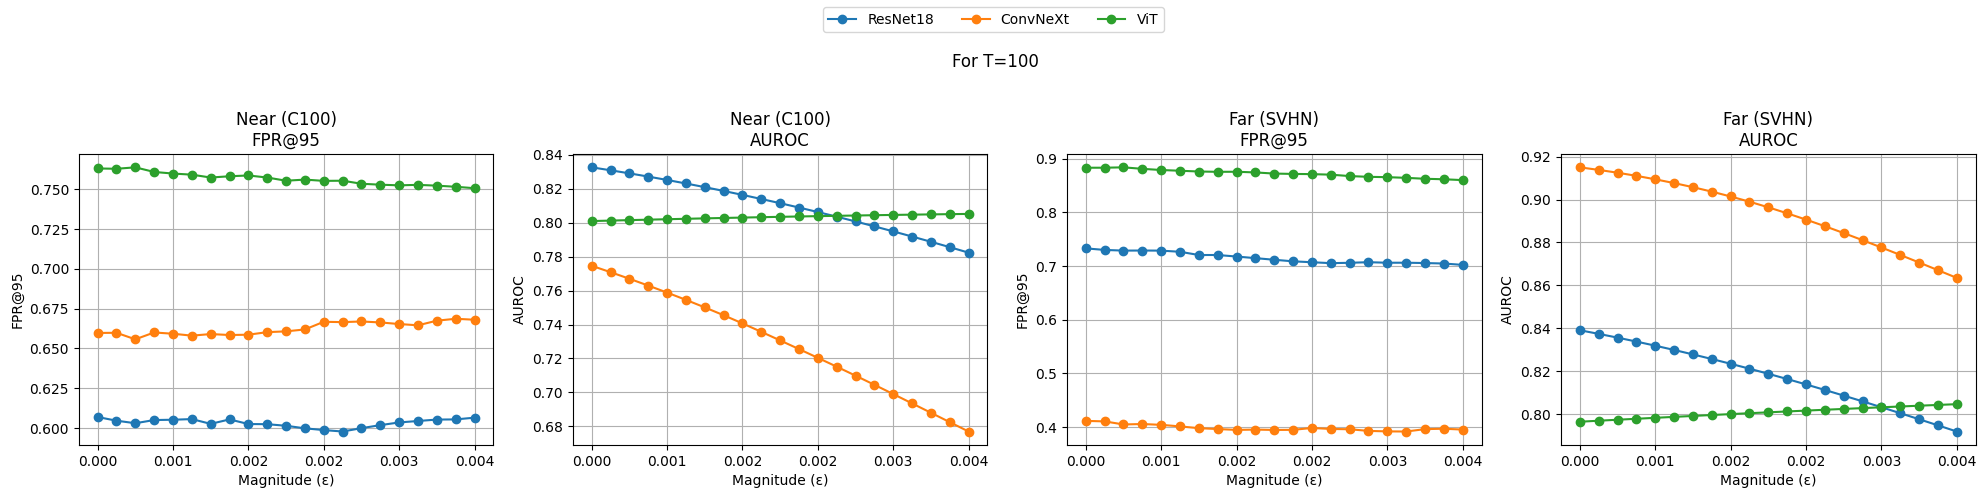

In [37]:
temp_val = 100
df_odin = df_results[df_results['Metoda'] == 'ODIN']
df_odin_temps = df_odin[df_odin['T'] == temp_val]
architectures = df_odin_temps['Architektura'].unique()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
fig.suptitle(f"For T={temp_val}", y=0.9)

# --- Near: FPR@95 ---
for arch in architectures:
    sub = df_odin_temps[df_odin_temps['Architektura'] == arch].sort_values('EPS')
    axes[0].plot(sub['EPS'], sub['Near (C100) FPR@95'], marker='o', label=arch)

axes[0].set_title('Near (C100)\nFPR@95')
axes[0].set_xlabel('Magnitude (ε)')
axes[0].set_ylabel('FPR@95')
axes[0].grid(True)

# --- Near: AUROC ---
for arch in architectures:
    sub = df_odin_temps[df_odin_temps['Architektura'] == arch].sort_values('EPS')
    axes[1].plot(sub['EPS'], sub['Near (C100) AUROC'], marker='o')

axes[1].set_title('Near (C100)\nAUROC')
axes[1].set_xlabel('Magnitude (ε)')
axes[1].set_ylabel('AUROC')
axes[1].grid(True)

# --- Far: FPR@95 ---
for arch in architectures:
    sub = df_odin_temps[df_odin_temps['Architektura'] == arch].sort_values('EPS')
    axes[2].plot(sub['EPS'], sub['Far (SVHN) FPR@95'], marker='o')

axes[2].set_title('Far (SVHN)\nFPR@95')
axes[2].set_xlabel('Magnitude (ε)')
axes[2].set_ylabel('FPR@95')
axes[2].grid(True)

# --- Far: AUROC ---
for arch in architectures:
    sub = df_odin_temps[df_odin_temps['Architektura'] == arch].sort_values('EPS')
    axes[3].plot(sub['EPS'], sub['Far (SVHN) AUROC'], marker='o')

axes[3].set_title('Far (SVHN)\nAUROC')
axes[3].set_xlabel('Magnitude (ε)')
axes[3].set_ylabel('AUROC')
axes[3].grid(True)


unique_eps = sorted(df_odin_temps['EPS'].unique())
ticks_to_show = unique_eps[::4]

for ax in axes:
    ax.set_xticks(ticks_to_show)
    ax.set_xticklabels([f"{v:.3f}" for v in ticks_to_show])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(architectures))
plt.tight_layout(rect=[0, 0, 1, 0.88])
filename = f"ODIN_T={temp_val}.png"
plt.savefig(os.path.join("/content/drive/MyDrive/SN/", filename), dpi=100)
plt.show()
